# 따릉이 수요 예측 머신러닝 분석 파이프라인

## 1. 라이브러리 로드 및 설정

In [14]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost loaded successfully")
except ImportError:
    HAS_XGB = False
    print("[Warning] XGBoost not found -> pip install xgboost")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"


XGBoost loaded successfully


In [15]:
# pip install xgboost

## 2. 설정값 및 데이터 로드

In [16]:
# ── Config ───────────────────────────────────────────────────
DATA_DIR       = Path("data")    # directory containing filtered_YYYYMM.csv
TEST_DAYS      = 30              # last 30 days as test set
TARGET_RENT_ID = "02128"        # target station ID

LONG_MISSING = {
    "02185": [("2022-09-18", "2022-10-23")],
    "02191": [("2022-10-05", "2022-10-21")],
    "02199": [("2022-01-22", "2022-02-07")],
}

# SARIMA/ARIMAX results for comparison (fill in after running SARIMA notebook)
SARIMA_RESULTS = {
    "RMSE": 0.640,
    "MAE": 0.524,
    "Asym.RMSE": 0.750,
    "Under-pred rate(%)": 26.2,
}
ARIMAX_RESULTS = {
    "RMSE": 0.599,
    "MAE": 0.455,
    "Asym.RMSE": 0.790,
    "Under-pred rate(%)": 46.2,
}

In [17]:
# ── Data loading (same as SARIMA notebook) ───────────────────
def load_filtered_csvs(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("filtered_2*.csv"))
    if not files:
        raise FileNotFoundError(f"No filtered_*.csv files found in: {data_dir}")
    parts = [
        pd.read_csv(f, dtype={"RENT_DATE": str, "RENT_TIME": str,
                               "RENT_ID": str, "CNT": int})
        for f in files
    ]
    df = pd.concat(parts, ignore_index=True)
    df["datetime"] = pd.to_datetime(
        df["RENT_DATE"] + df["RENT_TIME"].str.zfill(2),
        format="%Y%m%d%H"
    )
    return df

def make_series(df: pd.DataFrame, rent_id: str) -> pd.Series:
    sub = (
        df[df["RENT_ID"] == rent_id]
        .set_index("datetime")["CNT"]
        .sort_index()
    )
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq="h")
    sub = sub.reindex(full_idx, fill_value=0).astype(float)

    if rent_id in LONG_MISSING:
        for (start, end) in LONG_MISSING[rent_id]:
            sub[start:end] = np.nan

    is_na = sub.isna()
    sub = sub.interpolate(method="linear", limit=72, limit_direction="both")

    still_na = sub.isna()
    if still_na.any():
        tmp_df = pd.DataFrame({
            "CNT": sub, "DOW": sub.index.dayofweek, "HOUR": sub.index.hour
        })
        mean_table = tmp_df.groupby(["DOW", "HOUR"])["CNT"].mean()
        for idx in sub[still_na].index:
            sub[idx] = mean_table.get((idx.dayofweek, idx.hour), 0)
    return sub

def load_weather(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("*_weather.csv"))
    parts = []
    for f in files:
        df = pd.read_csv(f, encoding="cp949",
                         usecols=["일시", "기온(°C)"],
                         dtype={"기온(°C)": float})
        parts.append(df)
    weather = pd.concat(parts, ignore_index=True)
    weather["datetime"] = pd.to_datetime(weather["일시"])
    weather = (
        weather.set_index("datetime")
        .drop(columns=["일시"])
        .rename(columns={"기온(°C)": "temp"})
        .sort_index()
        .resample("h").mean()
    )
    weather["temp"] = weather["temp"].interpolate(method="linear")
    return weather

df_raw    = load_filtered_csvs(DATA_DIR)
series    = make_series(df_raw, TARGET_RENT_ID)
weather_df = load_weather(DATA_DIR)

print(f"Station {TARGET_RENT_ID} — {len(series):,} hours")
print(f"Weather — {len(weather_df):,} hours")


Station 02128 — 43,821 hours
Weather — 43,824 hours


## 3. Feature Engineering
ML 모델은 SARIMA와 달리 시계열 구조를 자동으로 학습하지 못하기 때문에,  
**시간 정보와 과거 값(lag features)을 직접 피처로 만들어줘야 해.**

| Feature | 설명 |
|---------|------|
| hour | 시간대 (0~23) → 일일 패턴 |
| dayofweek | 요일 (0=월 ~ 6=일) → 주간 패턴 |
| month | 월 (1~12) → 연간 계절성 |
| is_weekend | 주말 여부 |
| lag_1 | 1시간 전 수요 |
| lag_24 | 24시간(1일) 전 수요 |
| lag_168 | 168시간(1주일) 전 수요 |
| rolling_mean_24 | 최근 24시간 평균 수요 |
| rolling_mean_168 | 최근 168시간 평균 수요 |
| temp | 기온 (기상 외생변수) |


In [18]:
def make_features(series: pd.Series,
                  weather_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build feature matrix for ML models.
    Time features + lag features + weather.
    """
    df = pd.DataFrame({"CNT": series})

    # Time features (annual/weekly/daily seasonality)
    df["hour"]       = df.index.hour
    df["dayofweek"]  = df.index.dayofweek
    df["month"]      = df.index.month
    df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

    # Lag features (past demand)
    df["lag_1"]   = df["CNT"].shift(1)    # 1h ago
    df["lag_24"]  = df["CNT"].shift(24)   # 1 day ago
    df["lag_168"] = df["CNT"].shift(168)  # 1 week ago

    # Rolling mean features
    df["rolling_mean_24"]  = df["CNT"].shift(1).rolling(24).mean()
    df["rolling_mean_168"] = df["CNT"].shift(1).rolling(168).mean()

    # Weather feature (temperature)
    df["temp"] = weather_df["temp"].reindex(df.index).ffill()

    # Drop rows with NaN (from lag/rolling)
    df = df.dropna()
    return df

df_feat = make_features(series, weather_df)
print(f"Feature matrix: {df_feat.shape}")
print(f"Features: {[c for c in df_feat.columns if c != 'CNT']}")
df_feat.head()


Feature matrix: (43653, 11)
Features: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'temp']


,CNT,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,temp
2021-01-08 00:00:00,0.0,0,4,1,0,0.0,0.0,1.0,0.041667,0.363095,-15.9
2021-01-08 01:00:00,0.0,1,4,1,0,0.0,0.0,0.0,0.041667,0.357143,-16.5
2021-01-08 02:00:00,0.0,2,4,1,0,0.0,0.0,0.0,0.041667,0.357143,-16.9
2021-01-08 03:00:00,0.0,3,4,1,0,0.0,0.0,0.0,0.041667,0.357143,-17.2
2021-01-08 04:00:00,0.0,4,4,1,0,0.0,0.0,0.0,0.041667,0.357143,-17.5


## 4. Train / Test Split

In [19]:
# Weekday only (same as SARIMA notebook)
df_weekday = df_feat[df_feat.index.dayofweek < 5]

test_hours = TEST_DAYS * 24
train_df = df_weekday.iloc[:-test_hours]
test_df  = df_weekday.iloc[-test_hours:]

FEATURE_COLS = [c for c in df_feat.columns if c != "CNT"]

X_train = train_df[FEATURE_COLS]
y_train = train_df["CNT"]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df["CNT"]

print(f"Train: {train_df.index[0]} ~ {train_df.index[-1]} ({len(train_df):,} rows)")
print(f"Test : {test_df.index[0]} ~ {test_df.index[-1]} ({len(test_df):,} rows)")
print(f"Features: {FEATURE_COLS}")


Train: 2021-01-08 00:00:00 ~ 2025-11-19 20:00:00 (30,453 rows)
Test : 2025-11-19 21:00:00 ~ 2025-12-31 20:00:00 (720 rows)
Features: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'temp']


## 5. Evaluation Function

In [20]:
def asymmetric_rmse(actual: np.ndarray, forecast: np.ndarray,
                    alpha: float = 2.0) -> float:
    """Asymmetric RMSE: penalizes under-prediction by alpha."""
    errors = forecast - actual
    loss = np.where(errors < 0, alpha * errors**2, errors**2)
    return float(np.sqrt(loss.mean()))


def evaluate_ml_forecast(y_test: pd.Series, y_pred: np.ndarray,
                          model_name: str, alpha: float = 2.0) -> dict:
    forecast = pd.Series(y_pred, index=y_test.index)
    errors   = forecast - y_test

    rmse      = np.sqrt(mean_squared_error(y_test, forecast))
    mae       = mean_absolute_error(y_test, forecast)
    asym      = asymmetric_rmse(y_test.values, y_pred, alpha=alpha)
    under_rate = (errors < 0).mean() * 100

    print(f"[{model_name}]")
    print(f"  RMSE            : {rmse:.3f}")
    print(f"  MAE             : {mae:.3f}")
    print(f"  Asymmetric RMSE : {asym:.3f}  (alpha={alpha})")
    print(f"  Under-pred rate : {under_rate:.1f}%  <- bike shortage risk")

    # Visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(y_test.index, y_test.values, label="Actual (y)", alpha=0.7)
    axes[0].plot(forecast.index, forecast.values,
                 label=f"Forecast ({model_name})", linestyle="--", alpha=0.8)
    axes[0].set_title(f"Forecast vs Actual - {model_name}  "
                      f"[RMSE={rmse:.3f} | Asym.RMSE={asym:.3f}]")
    axes[0].legend()

    colors = ["red" if e < 0 else "steelblue" for e in errors]
    axes[1].bar(range(len(errors)), errors.values, color=colors, alpha=0.6, width=1)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"Forecast Error | Red=Under, Blue=Over | "
                      f"Under-pred={under_rate:.1f}%")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        f"Asym.RMSE(alpha={alpha})": round(asym, 3),
        "Under-pred rate(%)": round(under_rate, 1),
    }

ALPHA = 2.0

## 6. Random Forest
트리 기반 앙상블 모델. lag feature와 시간 피처를 활용해 비선형 패턴을 학습.


Random Forest fitting complete

Feature Importances:
hour                0.393876
rolling_mean_168    0.265302
rolling_mean_24     0.110891
temp                0.089476
lag_1               0.046117
month               0.026929
lag_168             0.025674
dayofweek           0.021298
lag_24              0.020438
is_weekend          0.000000


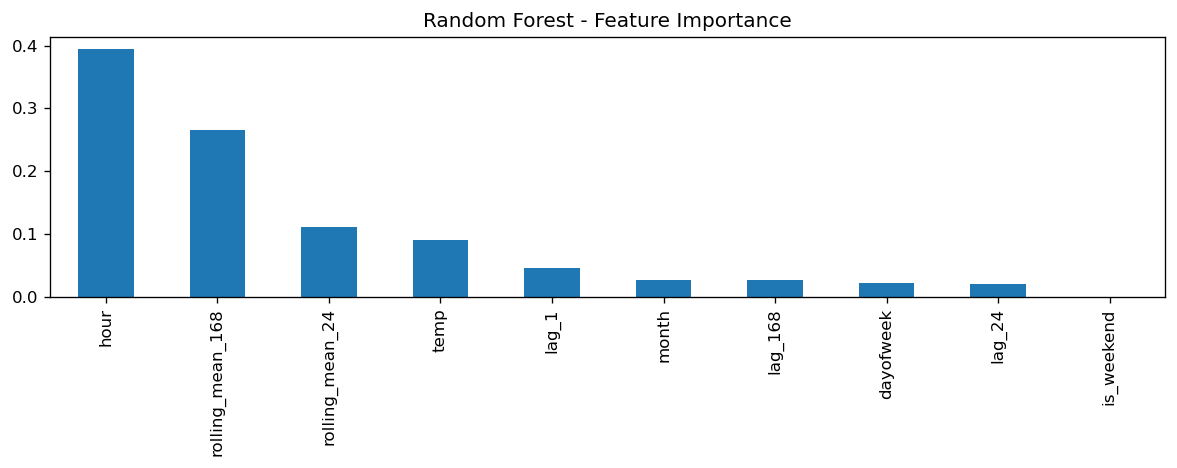

In [21]:
# Random Forest fitting
rf_model = RandomForestRegressor(
    n_estimators=200,     # 트리 개수
    max_depth=10,         # 트리 최대 깊이
    min_samples_leaf=5,   # 리프 노드 최소 샘플 수
    n_jobs=-1,            # 병렬 처리
    random_state=42,
)
rf_model.fit(X_train, y_train)
print("Random Forest fitting complete")

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)
print("\nFeature Importances:")
print(importances.to_string())

# Plot feature importance
importances.plot(kind="bar", figsize=(10, 4),
                 title="Random Forest - Feature Importance")
plt.tight_layout()
plt.show()

[Random Forest]
  RMSE            : 0.601
  MAE             : 0.483
  Asymmetric RMSE : 0.762  (alpha=2.0)
  Under-pred rate : 27.9%  <- bike shortage risk


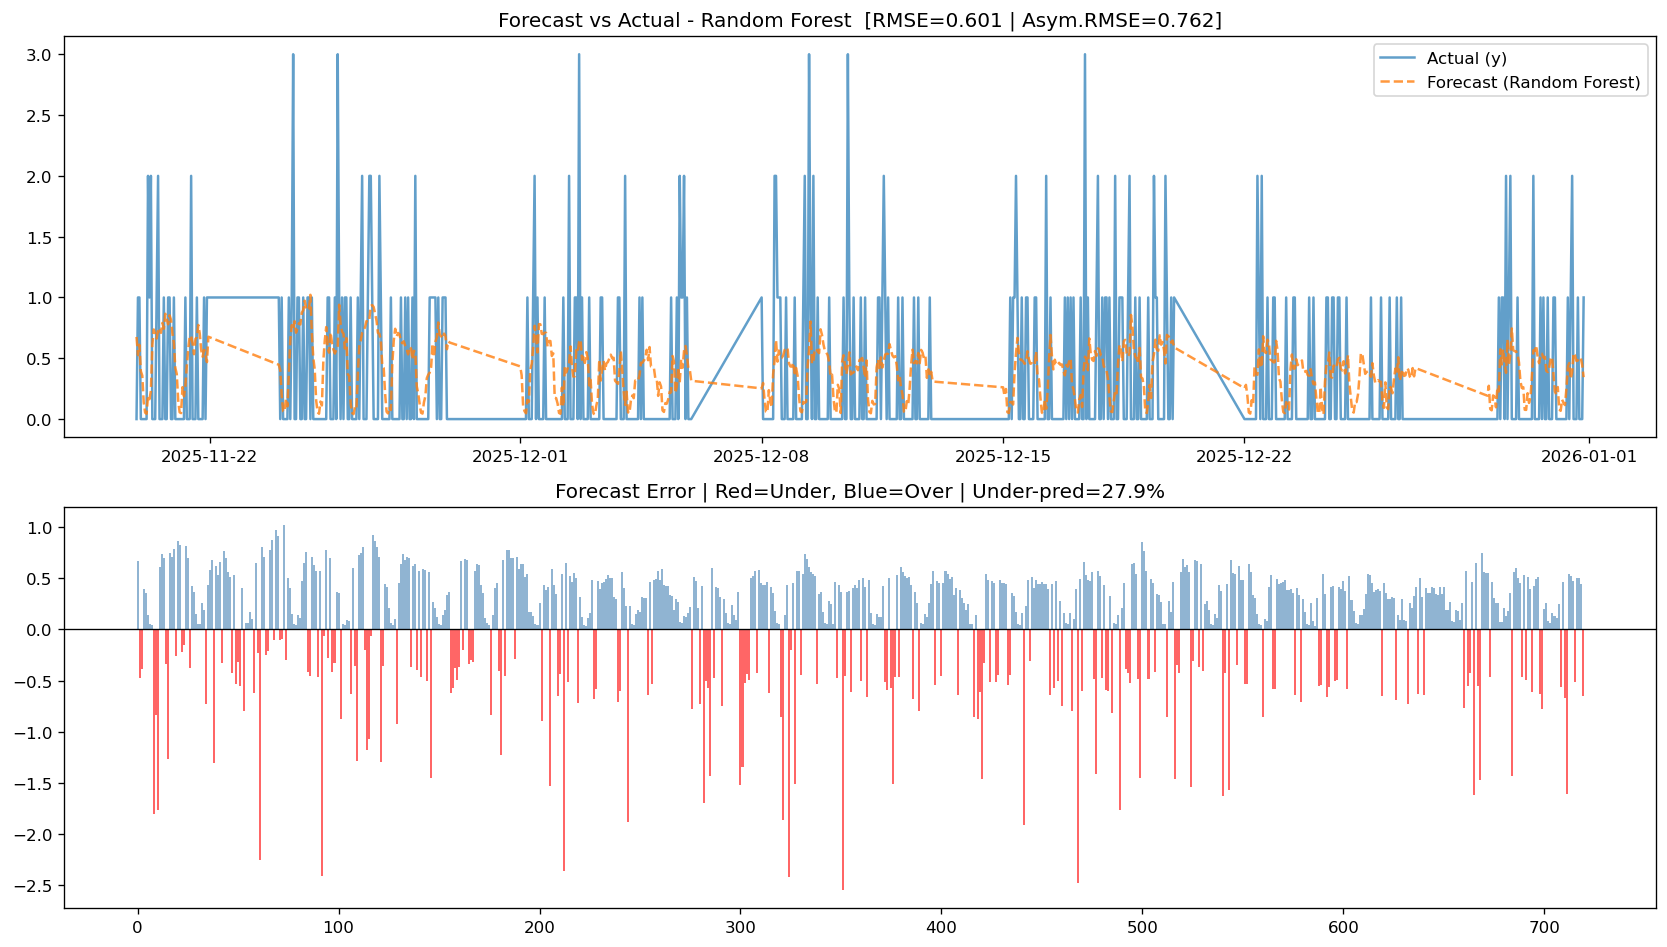

In [22]:
# Random Forest forecast evaluation
y_pred_rf = rf_model.predict(X_test)
perf_rf   = evaluate_ml_forecast(y_test, y_pred_rf,
                                  model_name="Random Forest", alpha=ALPHA)

## 7. XGBoost
Gradient Boosting 기반 모델. 순차적으로 트리를 추가해 잔차를 줄여나감.


XGBoost fitting complete

Feature Importances:
hour                0.250523
rolling_mean_168    0.157664
lag_1               0.131263
rolling_mean_24     0.111713
lag_168             0.090779
lag_24              0.077944
temp                0.071940
month               0.057172
dayofweek           0.051002
is_weekend          0.000000


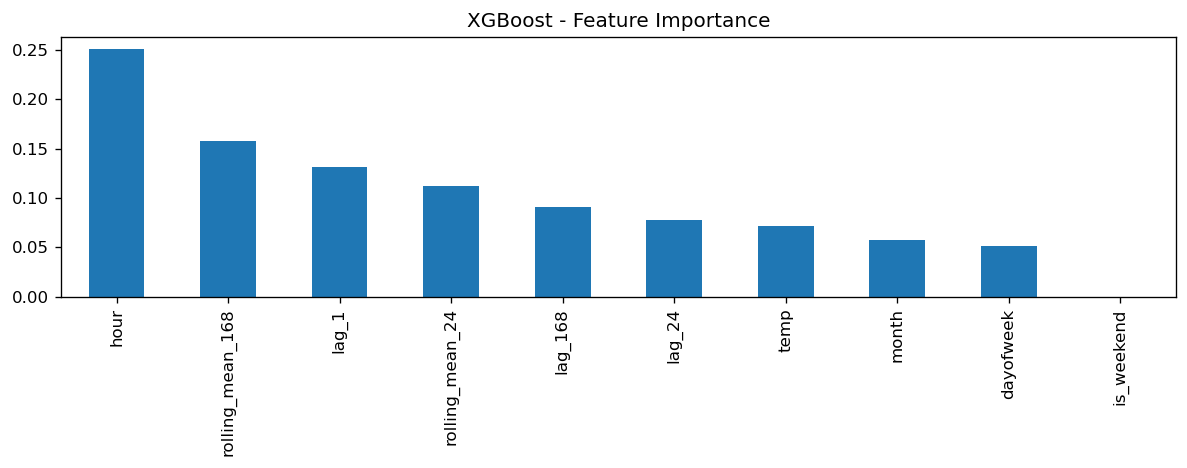

In [23]:
if HAS_XGB:
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    print("XGBoost fitting complete")

    # Feature importance
    xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
    xgb_imp = xgb_imp.sort_values(ascending=False)
    print("\nFeature Importances:")
    print(xgb_imp.to_string())

    xgb_imp.plot(kind="bar", figsize=(10, 4),
                 title="XGBoost - Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not installed. pip install xgboost")

[XGBoost]
  RMSE            : 0.599
  MAE             : 0.480
  Asymmetric RMSE : 0.763  (alpha=2.0)
  Under-pred rate : 27.9%  <- bike shortage risk


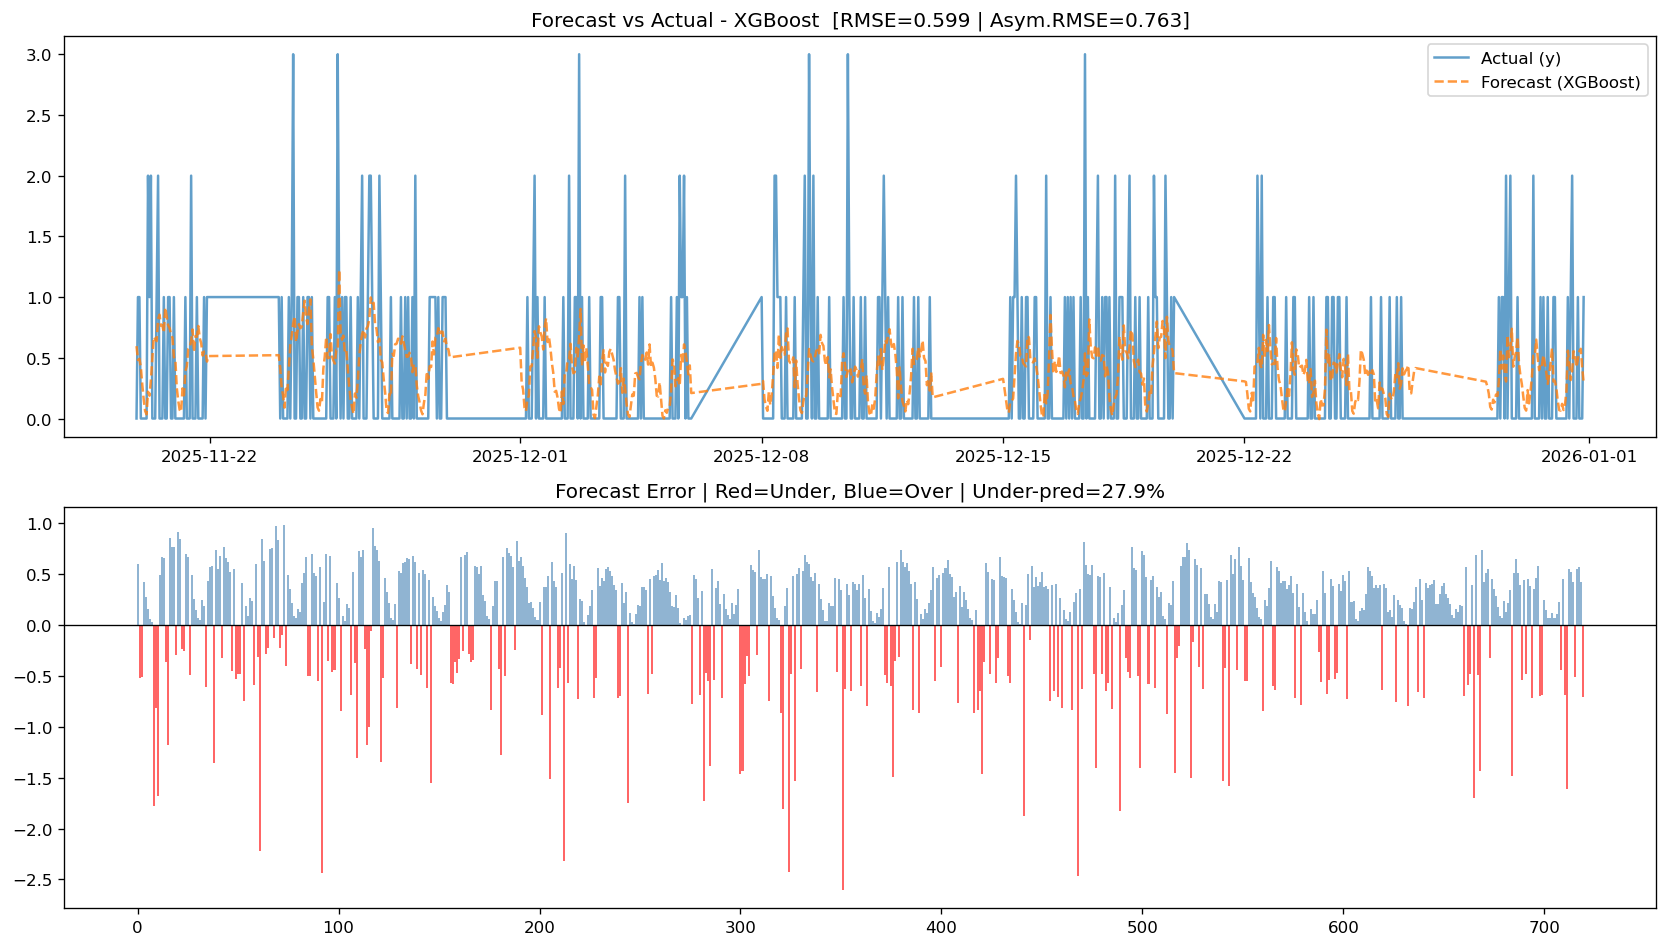

In [24]:
if HAS_XGB:
    y_pred_xgb = xgb_model.predict(X_test)
    perf_xgb   = evaluate_ml_forecast(y_test, y_pred_xgb,
                                       model_name="XGBoost", alpha=ALPHA)


In [25]:
# ── XGBoost with Asymmetric Loss Function ────────────────────
def asymmetric_obj(y_pred, dtrain, alpha=2.0):
    """
    Custom asymmetric loss for XGBoost (gradient & hessian).
    Under-prediction (y_pred < y_true): alpha * 2 * error
    Over-prediction  (y_pred >= y_true): 2 * error
    """
    y_true = dtrain.get_label()
    errors = y_pred - y_true

    grad = np.where(errors < 0,
                    alpha * 2 * errors,
                    2 * errors)
    hess = np.where(errors < 0,
                    alpha * 2 * np.ones_like(errors),
                    2 * np.ones_like(errors))
    return grad, hess

if HAS_XGB:
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest  = xgb.DMatrix(X_test,  label=y_test)

    params = {
        "max_depth":        6,
        "learning_rate":    0.05,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "seed":             42,
    }

    xgb_asym_model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=300,
        obj=lambda y_pred, dtrain: asymmetric_obj(y_pred, dtrain, alpha=ALPHA),
        evals=[(dtest, "test")],
        verbose_eval=False,
    )
    print("XGBoost (Asymmetric Loss) fitting complete")

XGBoost (Asymmetric Loss) fitting complete


[XGBoost (alpha=2.0)]
  RMSE            : 0.650
  MAE             : 0.549
  Asymmetric RMSE : 0.761  (alpha=2.0)
  Under-pred rate : 26.4%  <- bike shortage risk


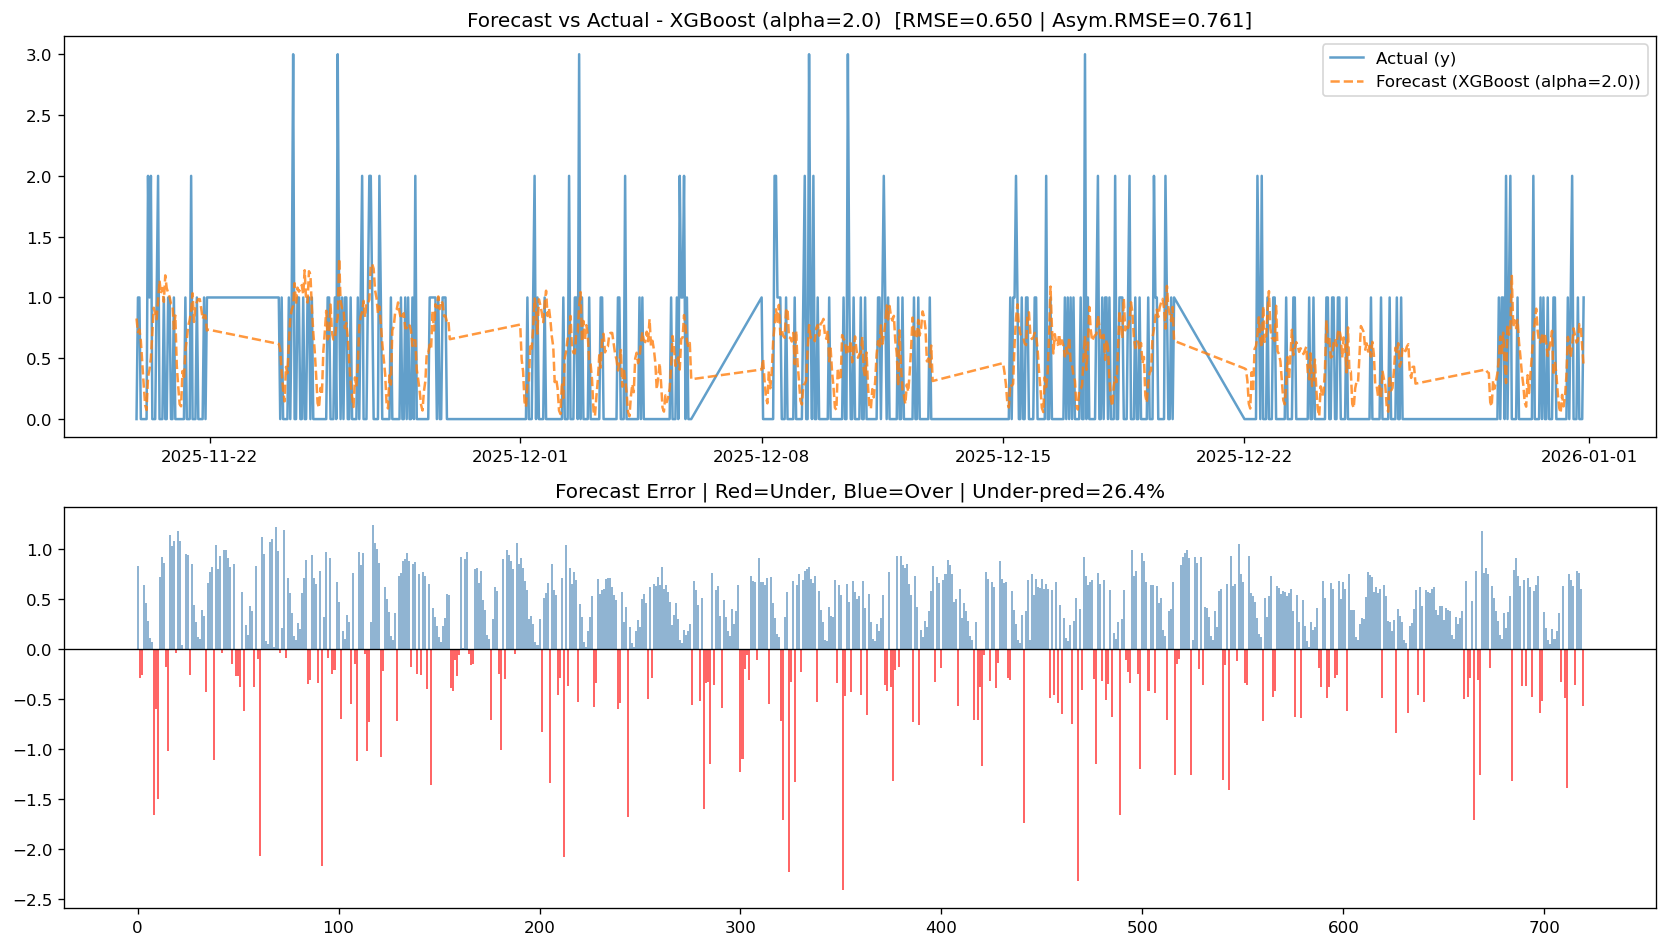

[XGBoost (alpha=3.0)]
  RMSE            : 0.699
  MAE             : 0.600
  Asymmetric RMSE : 0.861  (alpha=3.0)
  Under-pred rate : 24.4%  <- bike shortage risk


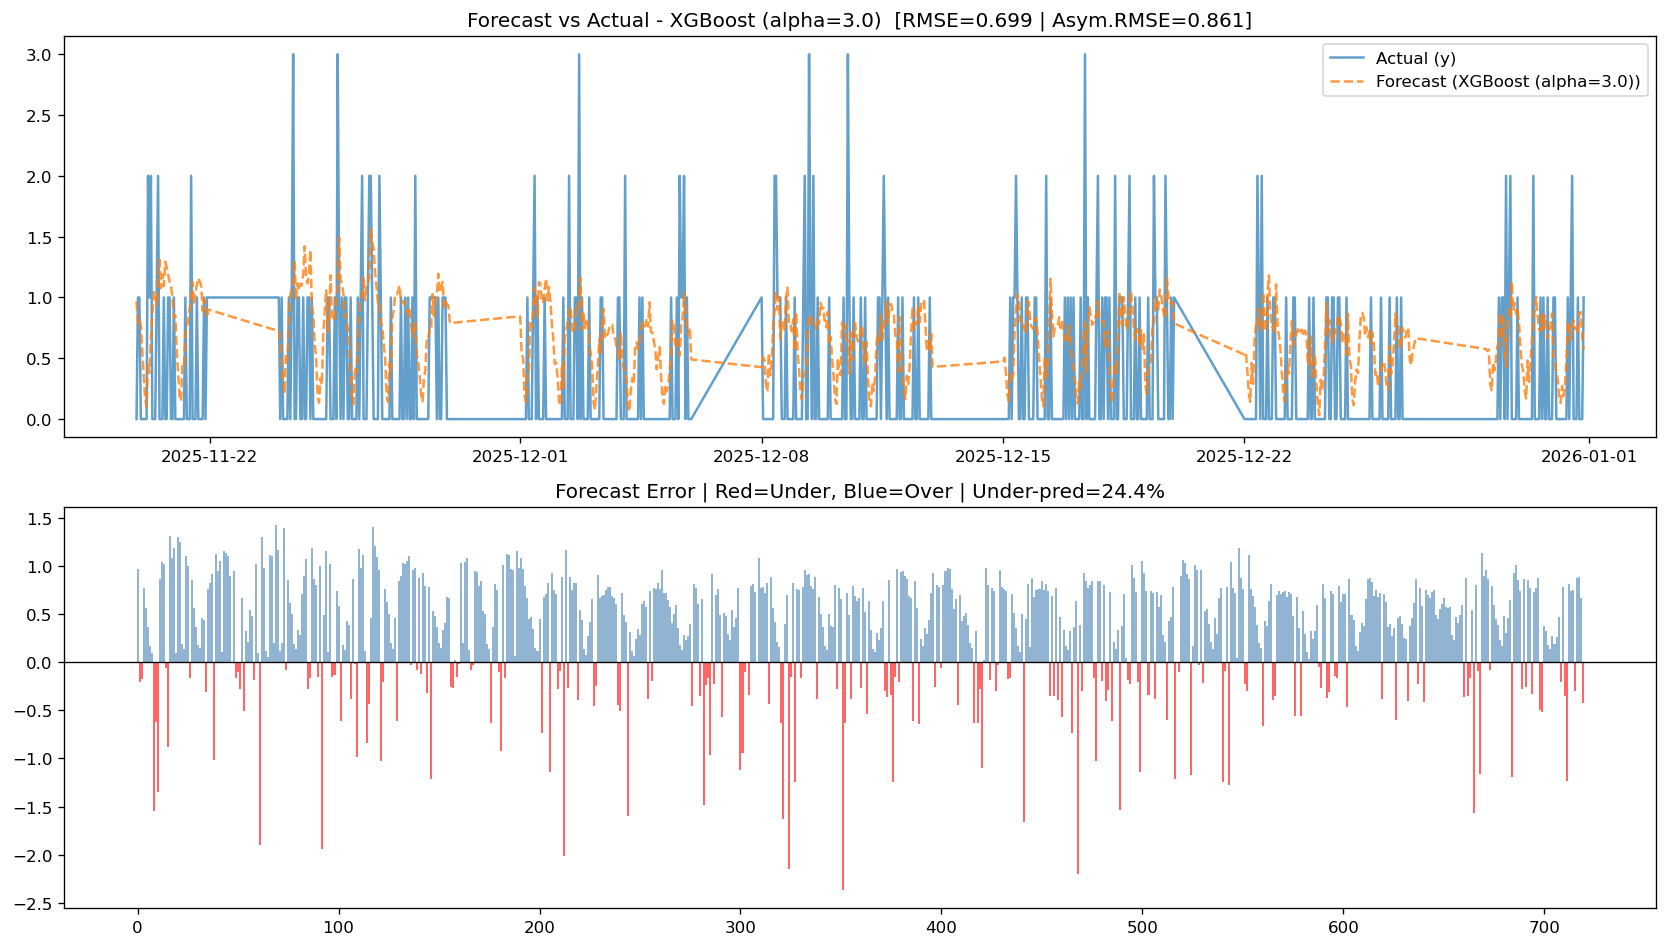

[XGBoost (alpha=5.0)]
  RMSE            : 0.783
  MAE             : 0.675
  Asymmetric RMSE : 0.998  (alpha=5.0)
  Under-pred rate : 20.3%  <- bike shortage risk


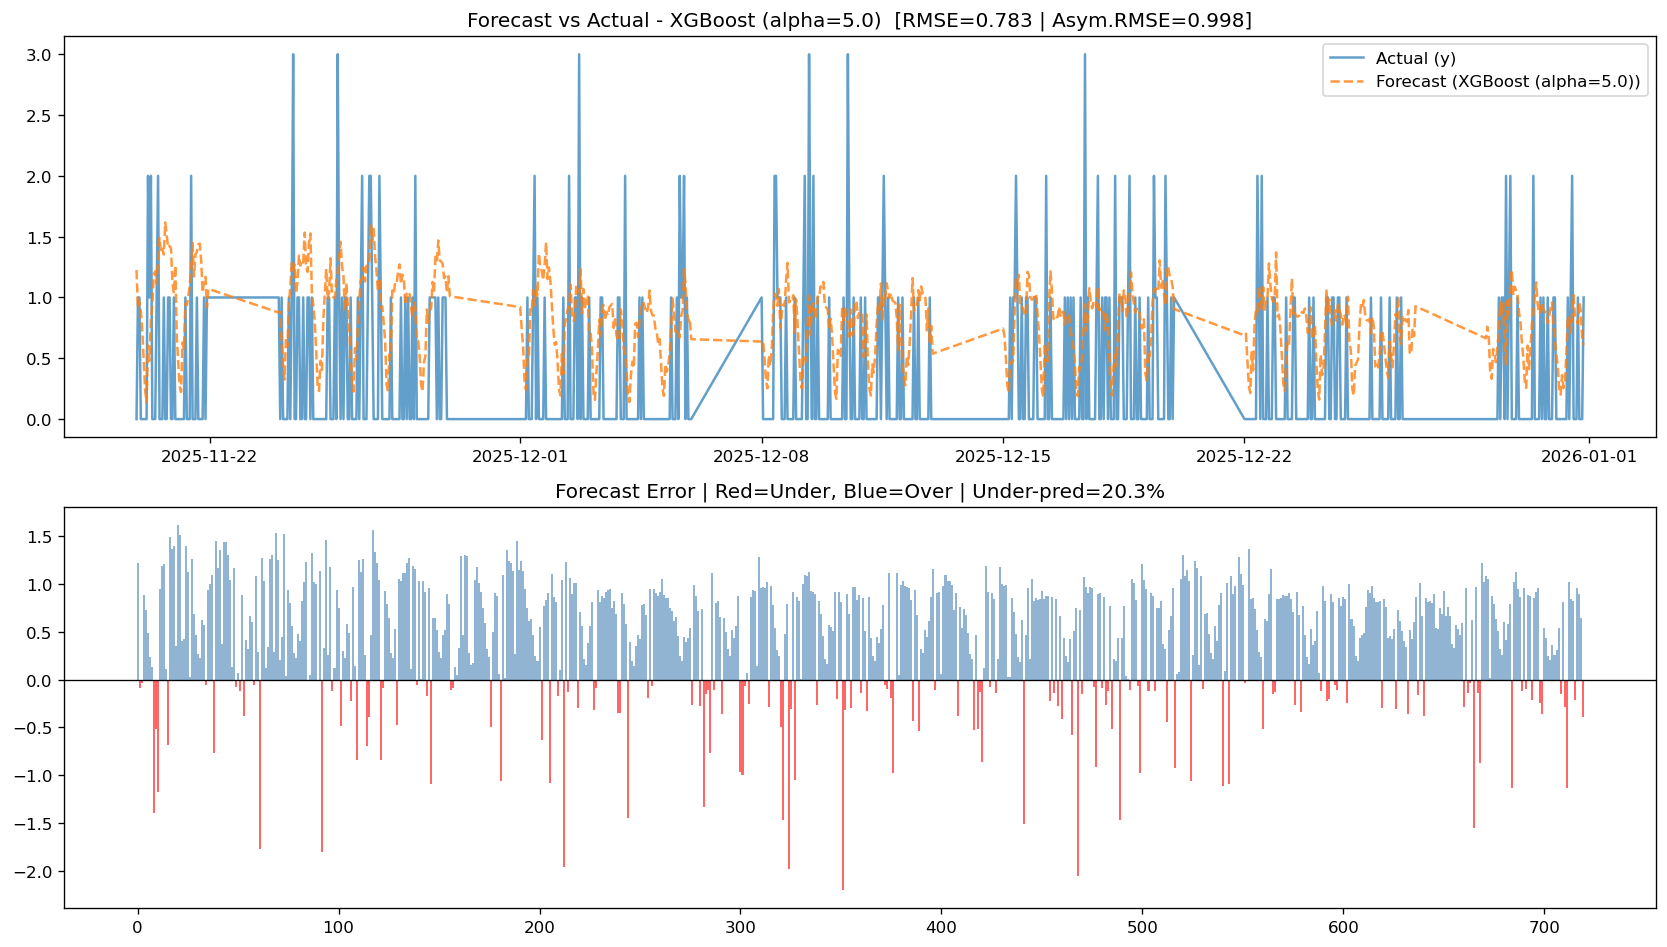

In [28]:
for alpha in [2.0, 3.0, 5.0]:
    xgb_asym_model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=300,
        obj=lambda y_pred, dtrain: asymmetric_obj(y_pred, dtrain, alpha=alpha),
        verbose_eval=False,
    )
    y_pred = xgb_asym_model.predict(dtest)
    perf = evaluate_ml_forecast(y_test, y_pred,
                                model_name=f"XGBoost (alpha={alpha})",
                                alpha=alpha)

    if alpha == 2.0:
        perf_xgb_asym = perf # alpha = 2 결과를 대표값으로 저장장

## 8. Model Comparison (SARIMA / ARIMAX / RF / XGBoost)


              Model Performance Comparison
                      RMSE    MAE  Asym.RMSE(alpha=2.0)  Under-pred rate(%)
model                                                                      
SARIMA               0.640  0.524                 0.750                26.2
ARIMAX               0.599  0.455                 0.790                46.2
Random Forest        0.601  0.483                 0.762                27.9
XGBoost              0.599  0.480                 0.763                27.9
XGBoost (alpha=2.0)  0.650  0.549                 0.761                26.4


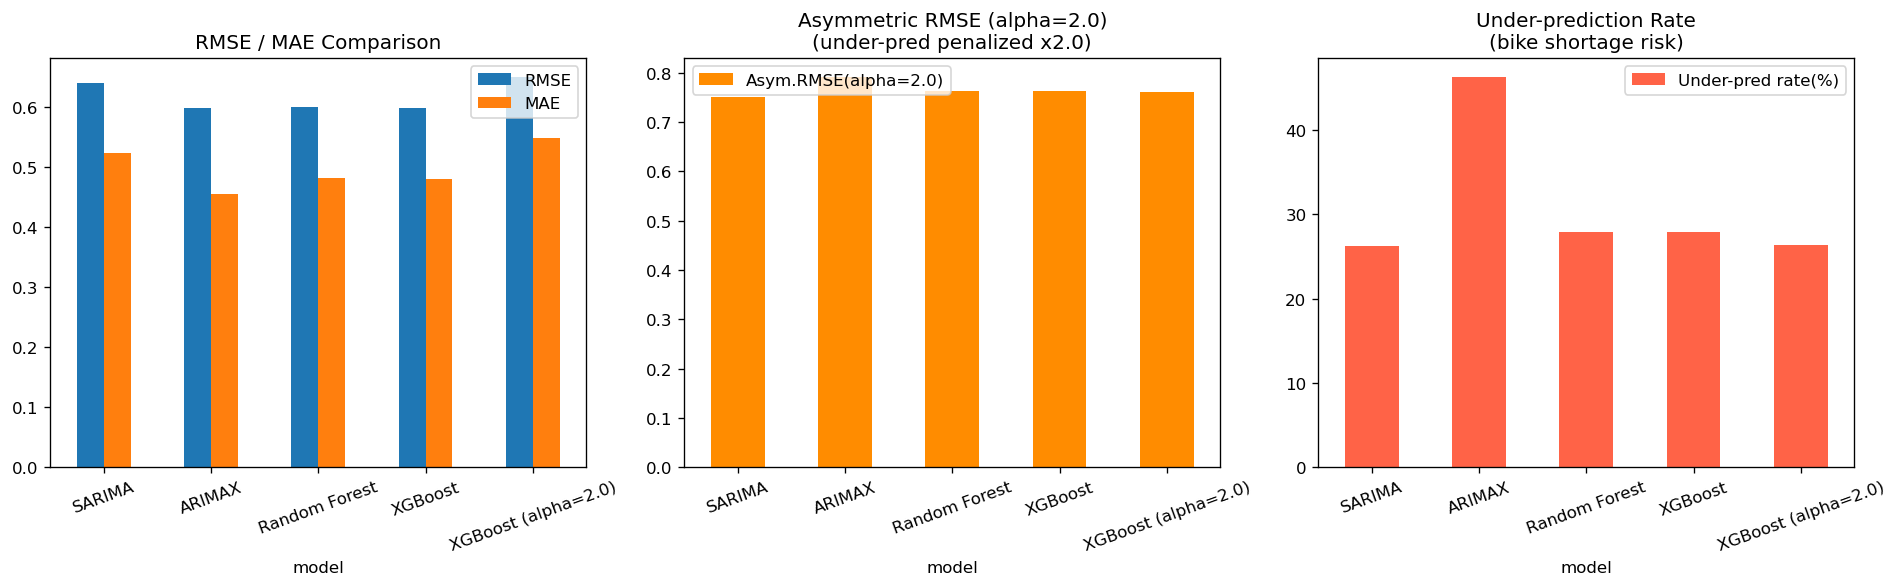

In [29]:
# Collect all results
all_results = []

# SARIMA
all_results.append({
    "model": "SARIMA",
    "RMSE": SARIMA_RESULTS["RMSE"],
    "MAE": SARIMA_RESULTS["MAE"],
    f"Asym.RMSE(alpha={ALPHA})": SARIMA_RESULTS["Asym.RMSE"],
    "Under-pred rate(%)": SARIMA_RESULTS["Under-pred rate(%)"],
})

# ARIMAX
all_results.append({
    "model": "ARIMAX",
    "RMSE": ARIMAX_RESULTS["RMSE"],
    "MAE": ARIMAX_RESULTS["MAE"],
    f"Asym.RMSE(alpha={ALPHA})": ARIMAX_RESULTS["Asym.RMSE"],
    "Under-pred rate(%)": ARIMAX_RESULTS["Under-pred rate(%)"],
})

# ML results
all_results.append(perf_rf)
all_results.append(perf_xgb)
if HAS_XGB:
    all_results.append(perf_xgb_asym)

# alpha=3, 5 결과 수동 추가 (위에서 돌린 결과 기반)
# 평일기준
SARIMA_RESULTS = {
    "RMSE": 0.647,
    "MAE": 0.484,
    "Asym.RMSE": 0.796,
    "Under-pred rate(%)": 25.7,
}
ARIMAX_RESULTS = {
    "RMSE": 0.651,
    "MAE": 0.505,
    "Asym.RMSE": 0.799,
    "Under-pred rate(%)": 38.2,
}

result_df = pd.DataFrame(all_results).set_index("model")
print("\n" + "="*65)
print("              Model Performance Comparison")
print("="*65)
print(result_df.to_string())

# Visualization
asym_col = f"Asym.RMSE(alpha={ALPHA})"
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

result_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0],
    title="RMSE / MAE Comparison", rot=20)

result_df[[asym_col]].plot(kind="bar", ax=axes[1],
    title=f"Asymmetric RMSE (alpha={ALPHA})\n(under-pred penalized x{ALPHA})",
    rot=20, color="darkorange")

result_df[["Under-pred rate(%)"]].plot(kind="bar", ax=axes[2],
    title="Under-prediction Rate\n(bike shortage risk)",
    rot=20, color="tomato")

plt.tight_layout()
plt.show()